#XGBoost Learning 参数调优

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import joblib
import time
import warnings
import os
os.chdir('D:/MY_Learning/matbench-dielectric/notebooks')
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']  # 中文不乱码
plt.rcParams['axes.unicode_minus'] = False              # 负号正常显示
warnings.filterwarnings('ignore')

# 加载数据
df = pd.read_csv('../data/dielectric_cleaned.csv')
X = df.drop('n_dielectric', axis=1)
y = np.log1p(df['n_dielectric'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("数据准备完成")
print(f"特征数: {X.shape[1]}")
print(f"训练集: {X_train.shape[0]} 样本")
print(f"测试集: {X_test.shape[0]} 样本")

# 加载 Day 16 调优的树参数模型
try:
    baseline_model = joblib.load('../models/day16_xgb_tuned_trees.pkl')
    baseline_params = baseline_model.get_params()
    print(f"\n✓ 加载了 Day 16 模型")
    print(f"  树参数: max_depth={baseline_params['max_depth']}, "
          f"subsample={baseline_params['subsample']}, "
          f"colsample_bytree={baseline_params['colsample_bytree']}")
    baseline_test_r2 = baseline_model.score(X_test, y_test)
    print(f"  测试集 R²: {baseline_test_r2:.4f}")
except:
    print("\n⚠️  未找到 Day 16 模型，将使用默认参数")
    baseline_params = {'max_depth': 6, 'subsample': 0.8, 'colsample_bytree': 0.8}
    baseline_test_r2 = None

数据准备完成
特征数: 135
训练集: 3811 样本
测试集: 953 样本

✓ 加载了 Day 16 模型
  树参数: max_depth=8, subsample=1.0, colsample_bytree=0.6
  测试集 R²: 0.6555



实验 1：learning_rate 与 n_estimators 的权衡

训练 lr=0.3, n_est=100...
  训练集 R²: 0.9967
  测试集 R²: 0.6555
  训练时间: 1.30s

训练 lr=0.1, n_est=300...
  训练集 R²: 0.9967
  测试集 R²: 0.6815
  训练时间: 2.83s

训练 lr=0.05, n_est=600...
  训练集 R²: 0.9967
  测试集 R²: 0.6768
  训练时间: 5.18s

训练 lr=0.01, n_est=3000...
  训练集 R²: 0.9967
  测试集 R²: 0.6858
  训练时间: 23.27s

结果汇总:
  lr  n_est  train_r2  test_r2      gap  train_time  total_learning
0.30    100  0.996658 0.655483 0.341175    1.298855            30.0
0.10    300  0.996697 0.681531 0.315165    2.830050            30.0
0.05    600  0.996727 0.676842 0.319885    5.182397            30.0
0.01   3000  0.996719 0.685762 0.310957   23.273663            30.0


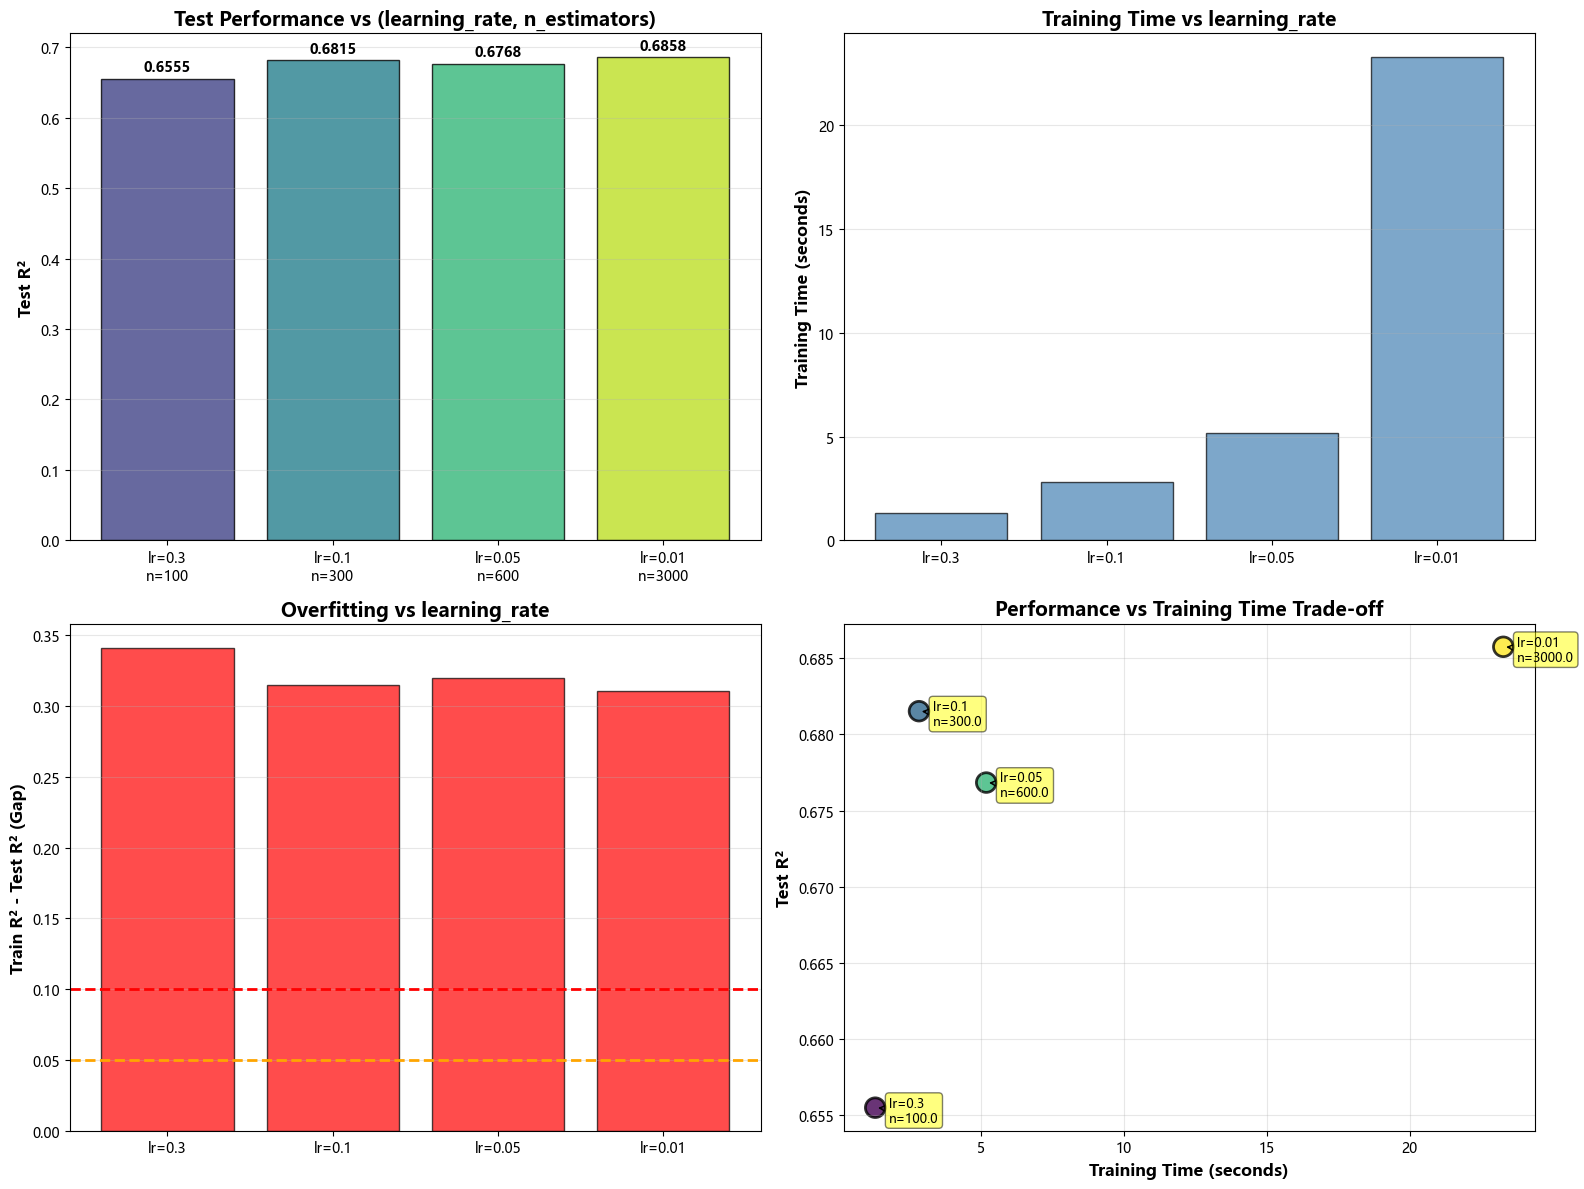


✓ learning_rate vs n_estimators 对比图已保存

最佳组合:
  learning_rate: 0.01
  n_estimators: 3000.0
  测试集 R²: 0.6858
  训练时间: 23.27s


In [16]:
#learning_rate vs n_estimators 权衡
print("\n" + "="*70)
print("实验 1：learning_rate 与 n_estimators 的权衡")
print("="*70)

# 定义不同的 (learning_rate, n_estimators) 组合
# 保持"总学习量"大致相同
lr_n_est_pairs = [
    (0.3, 100),    # 激进：大步快走
    (0.1, 300),    # 常用：平衡
    (0.05, 600),   # 保守：小步慢走
    (0.01, 3000)   # 极保守：需要很多树
]

results = []

for lr, n_est in lr_n_est_pairs:
    print(f"\n训练 lr={lr}, n_est={n_est}...")
    
    model = xgb.XGBRegressor(
        learning_rate=lr,
        n_estimators=n_est,
        max_depth=baseline_params['max_depth'],
        subsample=baseline_params['subsample'],
        colsample_bytree=baseline_params['colsample_bytree'],
        tree_method='hist',  # 加速，3000 棵树也需要它
        random_state=42,
        n_jobs=-1
    )
    
    start = time.time()
    model.fit(X_train, y_train, verbose=False)
    train_time = time.time() - start
    
    train_r2 = model.score(X_train, y_train)
    test_r2 = model.score(X_test, y_test)
    
    results.append({
        'lr': lr,
        'n_est': n_est,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'gap': train_r2 - test_r2,
        'train_time': train_time,
        'total_learning': lr * n_est  # "总学习量"
    })
    
    print(f"  训练集 R²: {train_r2:.4f}")
    print(f"  测试集 R²: {test_r2:.4f}")
    print(f"  训练时间: {train_time:.2f}s")

results_df = pd.DataFrame(results)

print("\n" + "="*70)
print("结果汇总:")
print("="*70)
print(results_df.to_string(index=False))

# 可视化
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 子图 1：测试集 R² vs learning_rate
ax1 = axes[0, 0]
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(results_df)))
bars = ax1.bar(range(len(results_df)), results_df['test_r2'], 
               color=colors, edgecolor='black', alpha=0.8)
ax1.set_xticks(range(len(results_df)))
ax1.set_xticklabels([f"lr={r['lr']}\nn={r['n_est']}" for r in results], rotation=0)
ax1.set_ylabel('Test R²', fontsize=12, fontweight='bold')
ax1.set_title('Test Performance vs (learning_rate, n_estimators)', 
              fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

# 添加数值标签
for i, (bar, val) in enumerate(zip(bars, results_df['test_r2'])):
    ax1.text(bar.get_x() + bar.get_width()/2., val + 0.005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 子图 2：训练时间对比
ax2 = axes[0, 1]
bars2 = ax2.bar(range(len(results_df)), results_df['train_time'], 
                color='steelblue', edgecolor='black', alpha=0.7)
ax2.set_xticks(range(len(results_df)))
ax2.set_xticklabels([f"lr={r['lr']}" for r in results], rotation=0)
ax2.set_ylabel('Training Time (seconds)', fontsize=12, fontweight='bold')
ax2.set_title('Training Time vs learning_rate', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# 子图 3：过拟合程度对比
ax3 = axes[1, 0]
colors_gap = ['green' if g < 0.05 else 'orange' if g < 0.10 else 'red' 
              for g in results_df['gap']]
bars3 = ax3.bar(range(len(results_df)), results_df['gap'], 
                color=colors_gap, edgecolor='black', alpha=0.7)
ax3.axhline(0.05, color='orange', linestyle='--', linewidth=2)
ax3.axhline(0.10, color='red', linestyle='--', linewidth=2)
ax3.set_xticks(range(len(results_df)))
ax3.set_xticklabels([f"lr={r['lr']}" for r in results], rotation=0)
ax3.set_ylabel('Train R² - Test R² (Gap)', fontsize=12, fontweight='bold')
ax3.set_title('Overfitting vs learning_rate', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

# 子图 4：性能 vs 训练时间权衡
ax4 = axes[1, 1]
scatter = ax4.scatter(results_df['train_time'], results_df['test_r2'], 
                      s=200, c=range(len(results_df)), cmap='viridis',
                      edgecolors='black', linewidths=2, alpha=0.8)

# 标注每个点
for i, row in results_df.iterrows():
    ax4.annotate(f"lr={row['lr']}\nn={row['n_est']}", 
                 xy=(row['train_time'], row['test_r2']),
                 xytext=(10, -10), textcoords='offset points',
                 fontsize=9, bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5),
                 arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

ax4.set_xlabel('Training Time (seconds)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Test R²', fontsize=12, fontweight='bold')
ax4.set_title('Performance vs Training Time Trade-off', fontsize=14, fontweight='bold')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/day17_lr_n_est_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ learning_rate vs n_estimators 对比图已保存")

# 分析最佳组合
best_idx = results_df['test_r2'].idxmax()
best_combo = results_df.loc[best_idx]

print(f"\n最佳组合:")
print(f"  learning_rate: {best_combo['lr']}")
print(f"  n_estimators: {best_combo['n_est']}")
print(f"  测试集 R²: {best_combo['test_r2']:.4f}")
print(f"  训练时间: {best_combo['train_time']:.2f}s")

In [17]:
# 准备验证集
print("\n" + "="*70)
print("实验 2：Early Stopping 机制")
print("="*70)

# 从训练集中划分出验证集
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

print(f"\n数据划分:")
print(f"  训练子集: {X_train_sub.shape[0]} 样本（用于训练）")
print(f"  验证集:   {X_val.shape[0]} 样本（用于 early_stopping）")
print(f"  测试集:   {X_test.shape[0]} 样本（最终评估）")


实验 2：Early Stopping 机制

数据划分:
  训练子集: 3048 样本（用于训练）
  验证集:   763 样本（用于 early_stopping）
  测试集:   953 样本（最终评估）


In [18]:
# 不用Early Stopping
print("\n[基准] 不用 early_stopping:")

model_no_es = xgb.XGBRegressor(
    n_estimators=1000,  # 训练 1000 棵树
    learning_rate=0.1,
    max_depth=baseline_params['max_depth'],
    subsample=baseline_params['subsample'],
    colsample_bytree=baseline_params['colsample_bytree'],
    tree_method='hist',  # 加速
    random_state=42,
    n_jobs=-1
)

# 训练时监控验证集（但不 early_stopping）
start = time.time()
model_no_es.fit(
    X_train_sub, y_train_sub,
    eval_set=[(X_train_sub, y_train_sub), (X_val, y_val)],
    verbose=False
)
time_no_es = time.time() - start

# 获取训练历史
evals_result_no_es = model_no_es.evals_result()
train_rmse_no_es = evals_result_no_es['validation_0']['rmse']
val_rmse_no_es = evals_result_no_es['validation_1']['rmse']

# 找到验证集最佳点
best_iter_no_es = np.argmin(val_rmse_no_es) + 1
best_val_rmse_no_es = min(val_rmse_no_es)

test_r2_no_es = model_no_es.score(X_test, y_test)

print(f"  训练了 1000 棵树")
print(f"  验证集最佳在第 {best_iter_no_es} 轮（RMSE={best_val_rmse_no_es:.4f}）")
print(f"  测试集 R²: {test_r2_no_es:.4f}")
print(f"  训练时间: {time_no_es:.2f}s")
print(f"  ⚠️  浪费了 {1000 - best_iter_no_es} 轮训练")


[基准] 不用 early_stopping:
  训练了 1000 棵树
  验证集最佳在第 329 轮（RMSE=0.1747）
  测试集 R²: 0.6664
  训练时间: 5.15s
  ⚠️  浪费了 671 轮训练


In [19]:
# 用 Early Stopping
print("\n[优化] 用 early_stopping_rounds=50:")

model_with_es = xgb.XGBRegressor(
    n_estimators=1000,  # 设一个大值
    learning_rate=0.1,
    max_depth=baseline_params['max_depth'],
    subsample=baseline_params['subsample'],
    colsample_bytree=baseline_params['colsample_bytree'],
    early_stopping_rounds=50,  # 50 轮不提升就停
    tree_method='hist',  # 加速
    random_state=42,
    n_jobs=-1
)

start = time.time()
model_with_es.fit(
    X_train_sub, y_train_sub,
    eval_set=[(X_val, y_val)],  # 只监控验证集
    verbose=False
)
time_with_es = time.time() - start

# 最佳迭代次数
best_iteration = model_with_es.best_iteration
best_score = model_with_es.best_score

test_r2_with_es = model_with_es.score(X_test, y_test)

print(f"  实际训练了 {best_iteration} 棵树（自动停止）")
print(f"  验证集最佳 RMSE: {best_score:.4f}")
print(f"  测试集 R²: {test_r2_with_es:.4f}")
print(f"  训练时间: {time_with_es:.2f}s")
print(f"  ✅ 节省了 {1000 - best_iteration} 棵树的训练时间")
print(f"  ✅ 时间节省: {(1 - time_with_es/time_no_es)*100:.1f}%")


[优化] 用 early_stopping_rounds=50:
  实际训练了 102 棵树（自动停止）
  验证集最佳 RMSE: 0.1749
  测试集 R²: 0.6673
  训练时间: 1.51s
  ✅ 节省了 898 棵树的训练时间
  ✅ 时间节省: 70.7%


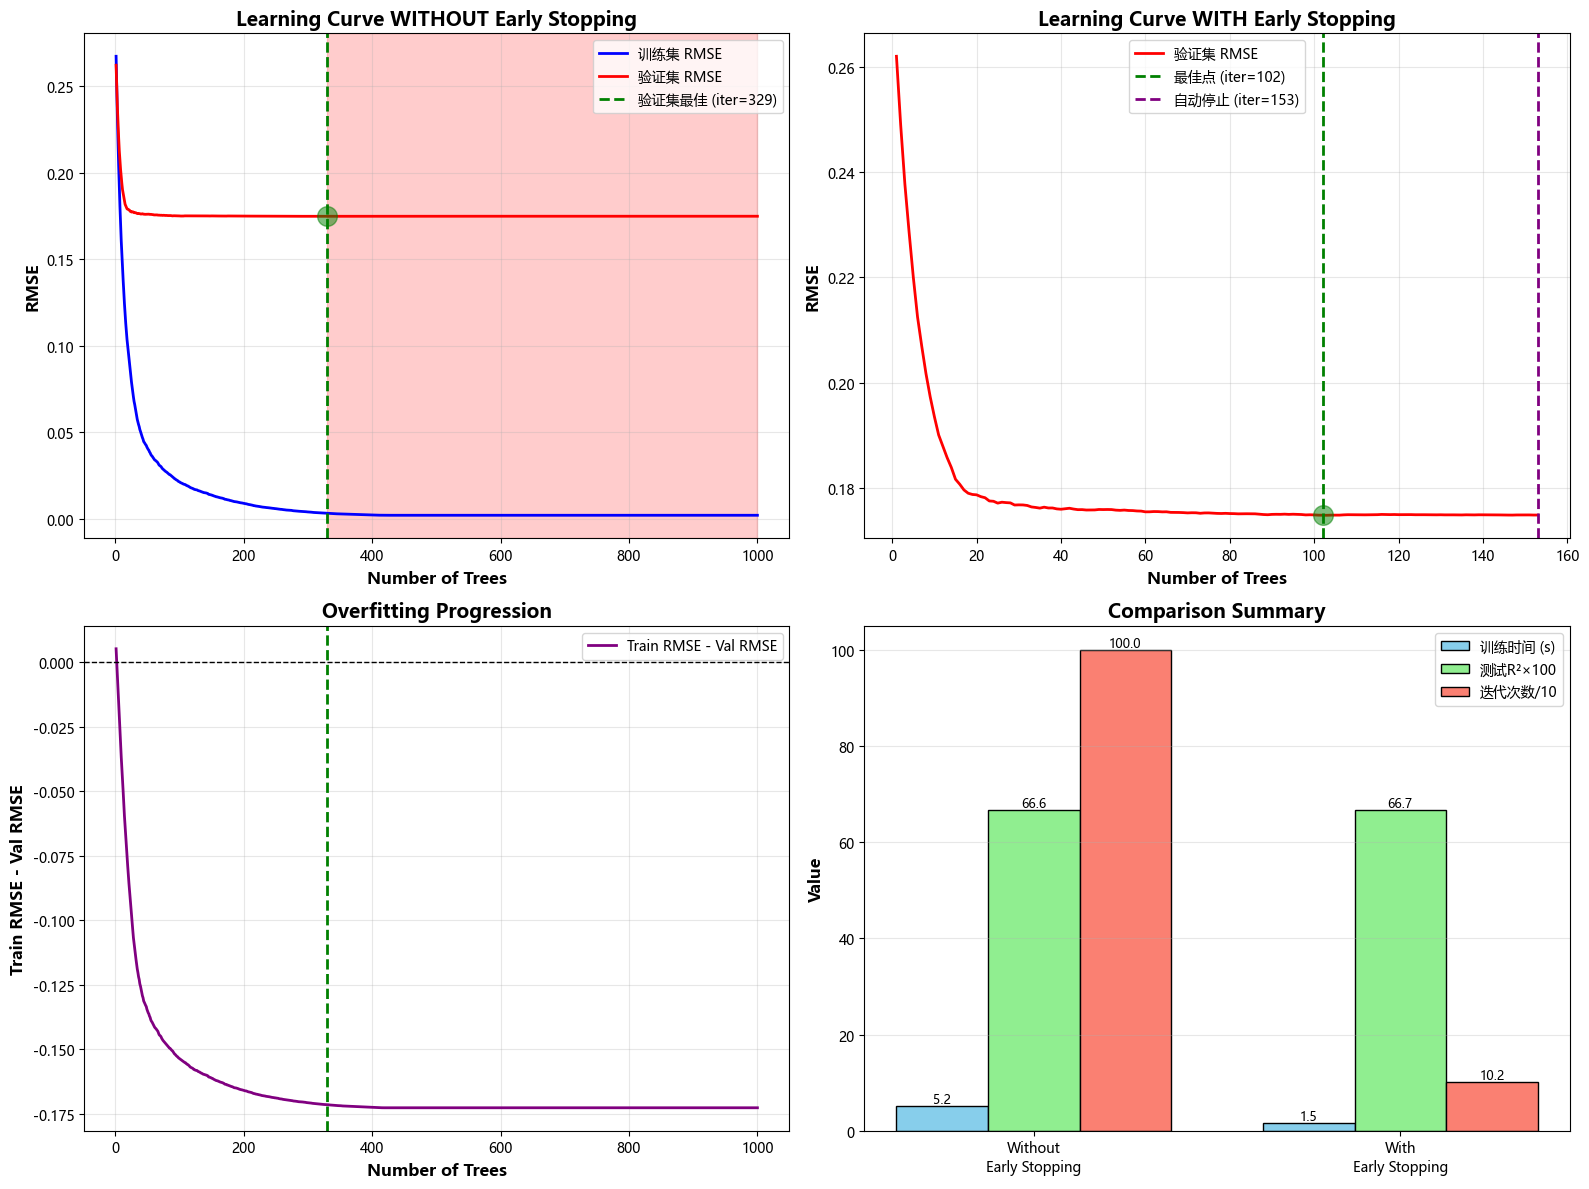


✓ Early Stopping 对比图已保存


In [20]:
# 可视化
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 子图 1：不用 early_stopping 的学习曲线
ax1 = axes[0, 0]
epochs = range(1, len(train_rmse_no_es) + 1)
ax1.plot(epochs, train_rmse_no_es, label='训练集 RMSE', linewidth=2, color='blue')
ax1.plot(epochs, val_rmse_no_es, label='验证集 RMSE', linewidth=2, color='red')
ax1.axvline(best_iter_no_es, color='green', linestyle='--', linewidth=2,
            label=f'验证集最佳 (iter={best_iter_no_es})')
ax1.scatter(best_iter_no_es, best_val_rmse_no_es, s=200, color='green', zorder=5, alpha=0.5)
ax1.set_xlabel('Number of Trees', fontsize=12, fontweight='bold')
ax1.set_ylabel('RMSE', fontsize=12, fontweight='bold')
ax1.set_title('Learning Curve WITHOUT Early Stopping', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 标注浪费的训练
ax1.axvspan(best_iter_no_es, 1000, alpha=0.2, color='red', 
            label=f'浪费了 {1000-best_iter_no_es} 轮')

# 子图 2：用 early_stopping 的学习曲线
ax2 = axes[0, 1]
evals_result_with_es = model_with_es.evals_result()
val_rmse_with_es = evals_result_with_es['validation_0']['rmse']
epochs_es = range(1, len(val_rmse_with_es) + 1)

ax2.plot(epochs_es, val_rmse_with_es, label='验证集 RMSE', linewidth=2, color='red')
ax2.axvline(best_iteration, color='green', linestyle='--', linewidth=2,
            label=f'最佳点 (iter={best_iteration})')
ax2.scatter(best_iteration, best_score, s=200, color='green', zorder=5, alpha=0.5)
ax2.axvline(len(val_rmse_with_es), color='purple', linestyle='--', linewidth=2,
            label=f'自动停止 (iter={len(val_rmse_with_es)})')
ax2.set_xlabel('Number of Trees', fontsize=12, fontweight='bold')
ax2.set_ylabel('RMSE', fontsize=12, fontweight='bold')
ax2.set_title('Learning Curve WITH Early Stopping', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 子图 3：过拟合进程对比
ax3 = axes[1, 0]
gap_no_es = np.array(train_rmse_no_es) - np.array(val_rmse_no_es)
ax3.plot(epochs, gap_no_es, linewidth=2, color='purple', label='Train RMSE - Val RMSE')
ax3.axhline(0, color='black', linestyle='--', linewidth=1)
ax3.axvline(best_iter_no_es, color='green', linestyle='--', linewidth=2)
ax3.set_xlabel('Number of Trees', fontsize=12, fontweight='bold')
ax3.set_ylabel('Train RMSE - Val RMSE', fontsize=12, fontweight='bold')
ax3.set_title('Overfitting Progression', fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 子图 4：时间和性能对比
ax4 = axes[1, 1]
methods = ['Without\nEarly Stopping', 'With\nEarly Stopping']
times = [time_no_es, time_with_es]
r2s = [test_r2_no_es, test_r2_with_es]
iterations = [1000, best_iteration]

x = np.arange(len(methods))
width = 0.25

bars1 = ax4.bar(x - width, times, width, label='训练时间 (s)', color='skyblue', edgecolor='black')
bars2 = ax4.bar(x, [r2*100 for r2 in r2s], width, label='测试R²×100', color='lightgreen', edgecolor='black')
bars3 = ax4.bar(x + width, [it/10 for it in iterations], width, label='迭代次数/10', color='salmon', edgecolor='black')

ax4.set_xticks(x)
ax4.set_xticklabels(methods)
ax4.set_ylabel('Value', fontsize=12, fontweight='bold')
ax4.set_title('Comparison Summary', fontsize=14, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

# 添加数值标签
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../figures/day17_early_stopping_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Early Stopping 对比图已保存")


实验 3：early_stopping_rounds 的影响

early_stopping_rounds=10:
  实际迭代: 102
  测试R²: 0.6673
  训练时间: 1.13s

early_stopping_rounds=20:
  实际迭代: 102
  测试R²: 0.6673
  训练时间: 1.23s

early_stopping_rounds=30:
  实际迭代: 102
  测试R²: 0.6673
  训练时间: 1.35s

early_stopping_rounds=50:
  实际迭代: 102
  测试R²: 0.6673
  训练时间: 1.47s

early_stopping_rounds=100:
  实际迭代: 328
  测试R²: 0.6666
  训练时间: 3.39s


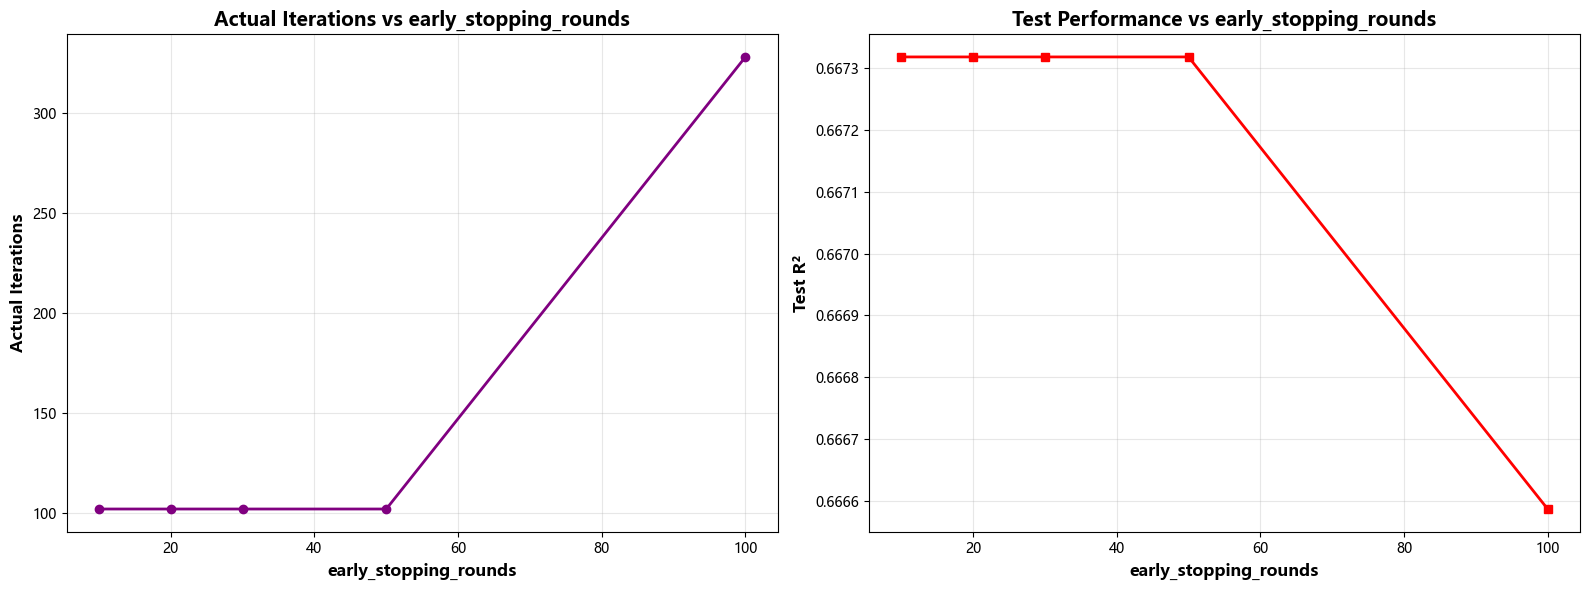


✓ early_stopping_rounds 分析图已保存


In [21]:
# 不同 early_stopping_rounds 的影响
print("\n" + "="*70)
print("实验 3：early_stopping_rounds 的影响")
print("="*70)

es_rounds_list = [10, 20, 30, 50, 100]
es_results = []

for es_rounds in es_rounds_list:
    print(f"\nearly_stopping_rounds={es_rounds}:")
    
    model = xgb.XGBRegressor(
        n_estimators=1000,
        learning_rate=0.1,
        early_stopping_rounds=es_rounds,
        max_depth=baseline_params['max_depth'],
        subsample=baseline_params['subsample'],
        colsample_bytree=baseline_params['colsample_bytree'],
        tree_method='hist',  # 加速
        random_state=42,
        n_jobs=-1
    )
    
    start = time.time()
    model.fit(
        X_train_sub, y_train_sub,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    train_time = time.time() - start
    
    actual_iters = model.best_iteration
    test_r2 = model.score(X_test, y_test)
    
    es_results.append({
        'es_rounds': es_rounds,
        'actual_iters': actual_iters,
        'test_r2': test_r2,
        'train_time': train_time
    })
    
    print(f"  实际迭代: {actual_iters}")
    print(f"  测试R²: {test_r2:.4f}")
    print(f"  训练时间: {train_time:.2f}s")

es_results_df = pd.DataFrame(es_results)

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 左图：实际迭代次数 vs es_rounds
ax1 = axes[0]
ax1.plot(es_results_df['es_rounds'], es_results_df['actual_iters'], 
         marker='o', linewidth=2, color='purple')
ax1.set_xlabel('early_stopping_rounds', fontsize=12, fontweight='bold')
ax1.set_ylabel('Actual Iterations', fontsize=12, fontweight='bold')
ax1.set_title('Actual Iterations vs early_stopping_rounds', 
              fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# 右图：测试集 R² vs es_rounds
ax2 = axes[1]
ax2.plot(es_results_df['es_rounds'], es_results_df['test_r2'], 
         marker='s', linewidth=2, color='red')
ax2.set_xlabel('early_stopping_rounds', fontsize=12, fontweight='bold')
ax2.set_ylabel('Test R²', fontsize=12, fontweight='bold')
ax2.set_title('Test Performance vs early_stopping_rounds', 
              fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/day17_es_rounds_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ early_stopping_rounds 分析图已保存")

In [22]:
print("\n" + "="*70)
print("训练最终模型")
print("="*70)

# 用全部训练集重新训练（不再需要验证集）
# 使用刚才找到的最佳迭代次数

final_model = xgb.XGBRegressor(
    n_estimators=best_iteration,  # 用 early_stopping 找到的次数
    learning_rate=0.1,
    max_depth=baseline_params['max_depth'],
    subsample=baseline_params['subsample'],
    colsample_bytree=baseline_params['colsample_bytree'],
    tree_method='hist',  # 加速
    random_state=42,
    n_jobs=-1
)

print(f"\n训练参数:")
print(f"  n_estimators: {best_iteration}（来自 early_stopping）")
print(f"  learning_rate: 0.1")
print(f"  max_depth: {baseline_params['max_depth']}")
print(f"  subsample: {baseline_params['subsample']}")
print(f"  colsample_bytree: {baseline_params['colsample_bytree']}")

final_model.fit(X_train, y_train, verbose=False)

# 最终评估
final_train_r2 = final_model.score(X_train, y_train)
final_test_r2 = final_model.score(X_test, y_test)

print(f"\n最终模型性能:")
print(f"  训练集 R²: {final_train_r2:.4f}")
print(f"  测试集 R²: {final_test_r2:.4f}")
print(f"  过拟合程度: {final_train_r2 - final_test_r2:.4f}")

# 对比 Day 16
if baseline_test_r2 is not None:
    improvement = final_test_r2 - baseline_test_r2
    print(f"\n相比 Day 16:")
    print(f"  Day 16 测试R²: {baseline_test_r2:.4f}")
    print(f"  Day 17 测试R²: {final_test_r2:.4f}")
    print(f"  提升: {improvement:+.4f} ({improvement/baseline_test_r2*100:+.2f}%)")

# 保存模型
joblib.dump(final_model, '../models/day17_xgb_tuned_learning.pkl')
print("\n✓ 最终模型已保存到 ../models/day17_xgb_tuned_learning.pkl")

# 保存调参结果
import json

# JSON 序列化安全转换
def to_python(obj):
    """递归转换 numpy 类型为 Python 原生类型"""
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, dict):
        return {k: to_python(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [to_python(v) for v in obj]
    return obj

learning_params_summary = {
    'best_learning_rate': 0.1,
    'best_n_estimators': int(best_iteration),
    'early_stopping_rounds': 50,
    'actual_iterations_used': int(best_iteration),
    'final_performance': {
        'train_r2': float(final_train_r2),
        'test_r2': float(final_test_r2),
        'overfitting_gap': float(final_train_r2 - final_test_r2)
    },
    'experiments': {
        'lr_n_est_pairs': to_python(results_df.to_dict('records')),
        'early_stopping_comparison': {
            'without_es_time': float(time_no_es),
            'with_es_time': float(time_with_es),
            'time_saved_pct': float((1 - time_with_es/time_no_es)*100)
        }
    }
}

with open('../models/day17_learning_params_tuning.json', 'w') as f:
    json.dump(learning_params_summary, f, indent=2)

print("✓ 调参结果已保存到 ../models/day17_learning_params_tuning.json")

# 最终总结
print("\n" + "="*70)
print("Day 17 总结")
print("="*70)

print(f"\nLearning 参数调优结果:")
print(f"  最佳 learning_rate: 0.1")
print(f"  最佳 n_estimators: {best_iteration}（通过 early_stopping 确定）")
print(f"  early_stopping_rounds: 50")

print(f"\n关键发现:")
print(f"  1. early_stopping 节省了 {(1 - time_with_es/time_no_es)*100:.1f}% 训练时间")
print(f"  2. learning_rate=0.1 在性能和速度间取得平衡")
print(f"  3. 实际只需 {best_iteration} 棵树（而不是 1000）")

print("="*70)


训练最终模型

训练参数:
  n_estimators: 102（来自 early_stopping）
  learning_rate: 0.1
  max_depth: 8
  subsample: 1.0
  colsample_bytree: 0.6

最终模型性能:
  训练集 R²: 0.9905
  测试集 R²: 0.6828
  过拟合程度: 0.3077

相比 Day 16:
  Day 16 测试R²: 0.6555
  Day 17 测试R²: 0.6828
  提升: +0.0274 (+4.17%)

✓ 最终模型已保存到 ../models/day17_xgb_tuned_learning.pkl
✓ 调参结果已保存到 ../models/day17_learning_params_tuning.json

Day 17 总结

Learning 参数调优结果:
  最佳 learning_rate: 0.1
  最佳 n_estimators: 102（通过 early_stopping 确定）
  early_stopping_rounds: 50

关键发现:
  1. early_stopping 节省了 70.7% 训练时间
  2. learning_rate=0.1 在性能和速度间取得平衡
  3. 实际只需 102 棵树（而不是 1000）
